In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u
from astropy import constants as const
from astropy.cosmology import Planck18, z_at_value

from scipy.integrate import quad
from scipy.optimize import curve_fit
#from ipynb.fs.full.Generator_trapz import *
#from ipynb.fs.full.Analytic_neutrino_flux import *
from GOALS_dataframe.analytic_neutrino_flux import *


import matplotlib.patches as patches


from gammapy.modeling.models import (
    EBL_DATA_BUILTIN,
    EBLAbsorptionNormSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)




In [2]:
DL = 17.5 * u.Mpc
gammasn=4.27
RSN=0.16
alphaAGN=0.01
z = z_at_value(Planck18.luminosity_distance, DL)
redshift = z.value

franceschini17 = EBLAbsorptionNormSpectralModel.read_builtin(
    "franceschini17", redshift=redshift
)

energyrange=franceschini17.energy.value*1e-6
AbsCoeff=franceschini17.data.value[int(round(redshift,3)*1000)-1]
AbsCoeff=AbsCoeff[energyrange>0.1]

energyrange=energyrange[energyrange>0.1]




In [3]:
#NGC2146_3 = [bulk_flux(i, 2500,250,150,500,0.1,1e10,4.11,1e8,0.28,50.7) for i in energy]
NGC2146_3a= Flux_gamma(energyrange, R=250,v=500,nism=2500,H=150,gammasn=gammasn,pmax=1e8,RSN=RSN,D_L=DL.value)*AbsCoeff*0.00160218 #to erg



In [4]:
dataNorth = pd.read_csv('CTAO_data/CTAOdata_North_50h.csv',sep=';', header=None, names=['X','Y'])
dataSouth = pd.read_csv('CTAO_data/CTAOdata_South_50h.csv',sep=';', header=None, names=['X','Y'])
dataNGC2146 = pd.read_csv('96/NGC2146_data.csv',sep=';', header=None, names=['X','Y'])
upperNGC2146 = pd.read_csv('96/NGC2146_upper.csv',sep=';', header=None, names=['X','Y'])
xyminNGC2146 = pd.read_csv('96/NGC2146_xymin.csv',sep=';', header=None, names=['X','Y']) #Uncertainty
xymaxNGC2146 = pd.read_csv('96/NGC2146_xymax.csv',sep=';', header=None, names=['X','Y'])
lowerleftNGC2146=pd.read_csv('96/NGC2146_lowerleft.csv',sep=';', header=None, names=['X','Y']) #Upper Uncertainty
rightNGC2146=pd.read_csv('96/NGC2146_right.csv',sep=';', header=None, names=['X','Y'])

tabdata=[dataNorth,dataSouth,dataNGC2146,upperNGC2146,xyminNGC2146,xymaxNGC2146,lowerleftNGC2146,rightNGC2146]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)

XNorth=dataNorth.X.astype('float64')*1e3 # to GeV
YNorth=dataNorth.Y.astype('float64')
XSouth=dataSouth.X.astype('float64')*1e3 # to GeV
YSouth=dataSouth.Y.astype('float64')

XNGC2146data=dataNGC2146.X.astype('float64')
YNGC2146data=dataNGC2146.Y.astype('float64')*0.00160218 #to erg
XminNGC2146data=xyminNGC2146.X.astype('float64')
YminNGC2146data=xyminNGC2146.Y.astype('float64')*0.00160218 #to erg
XmaxNGC2146data=xymaxNGC2146.X.astype('float64')
YmaxNGC2146data=xymaxNGC2146.Y.astype('float64')*0.00160218 #to erg

XNGC2146upper=upperNGC2146.X.astype('float64')
YNGC2146upper=upperNGC2146.Y.astype('float64')*0.00160218 #to erg
XminNGC2146upper=lowerleftNGC2146.X.astype('float64')
YminNGC2146upper=lowerleftNGC2146.Y.astype('float64')*0.00160218 #to erg
XmaxNGC2146upper=rightNGC2146.X.astype('float64')


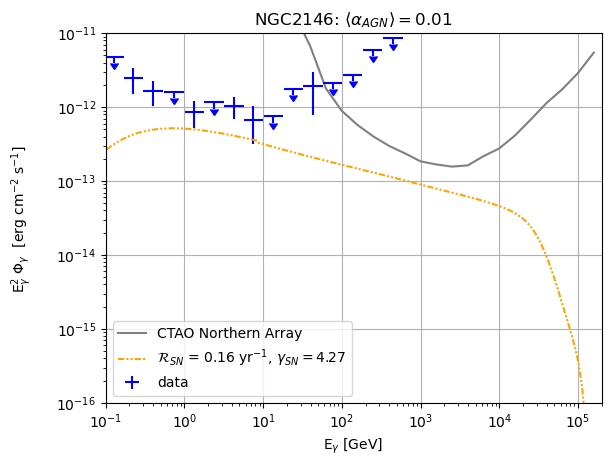

In [5]:
plt.plot(XNorth,YNorth,color="gray",label ="CTAO Northern Array")
#plt.plot(XSouth,YSouth,color="red",label ="CTAO Southern Array")
plt.errorbar(XNGC2146data,YNGC2146data,xerr=[XNGC2146data-XminNGC2146data,XmaxNGC2146data-XNGC2146data], yerr=[YNGC2146data-YminNGC2146data,YmaxNGC2146data-YNGC2146data], color="blue",fmt=',',label='data')
plt.errorbar(XNGC2146upper,YNGC2146upper,xerr=[XNGC2146upper-XminNGC2146upper,XmaxNGC2146upper-XNGC2146upper], yerr=YNGC2146upper-YminNGC2146upper,color="blue",uplims=True,fmt=',')

plt.plot(energyrange,NGC2146_3a, color = 'orange',linestyle = (0,(3,1,1,1,1,1)),label='$\mathcal{R}_{SN}$ = '+str(RSN)+' yr$^{-1}$, $\\gamma_{SN} = $'+ str(gammasn) )






plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-1,2e5) ; plt.ylim(1e-16,1e-11)
#plt.xlim(2e2,2e8) ; plt.ylim(9e-16,5e-9) #nu
plt.title(r"NGC2146: $ \langle \alpha_{AGN}\rangle=$"+ str(alphaAGN))
plt.xlabel('E$_{\\gamma}$ [GeV] ')
plt.ylabel('E$_{\\gamma}^2$ $\\Phi_{\\gamma}$  [erg cm$^{-2}$ s$^{-1}$] \n')
plt.legend(loc = 'lower left')
plt.grid()

#plt.savefig("./Figures/FluxplotNGC2146.pdf",bbox_inches="tight",dpi = 200)
